# Model Training & Evaluation - Heart Disease Classification

This notebook walks through:
1. Data preprocessing & feature engineering
2. Model training (Logistic Regression, Random Forest, Gradient Boosting)
3. Hyperparameter tuning with GridSearchCV
4. Cross-validation & evaluation
5. MLflow experiment tracking
6. Model comparison & selection

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay
)
from sklearn.pipeline import Pipeline
import mlflow

sns.set_theme(style='whitegrid')

sys.path.insert(0, os.path.join(os.getcwd(), '..', 'src'))
from preprocessing import preprocess
from feature_engineering import build_preprocessor, prepare_data

print('All imports successful')

All imports successful


## 1. Data Preparation

In [10]:
# Fetch data from UCI Repository and preprocess
df = preprocess(save=False)

X_train, X_test, y_train, y_test = prepare_data(df)
print(f'\nTrain: {X_train.shape}, Test: {X_test.shape}')
print(f'Train target: {y_train.value_counts().to_dict()}')
print(f'Test target: {y_test.value_counts().to_dict()}')

Loaded data: 303 rows, 14 columns
Missing values: 6
After imputation: 0 missing values
Target distribution: {0: 164, 1: 139}

Train: (242, 13), Test: (61, 13)
Train target: {0: 131, 1: 111}
Test target: {0: 33, 1: 28}


## 2. Feature Engineering Pipeline

In [11]:
preprocessor = build_preprocessor()

# Show the pipeline structure
print('Preprocessing Pipeline:')
print(f'  Numerical features (StandardScaler): {["age", "trestbps", "chol", "thalach", "oldpeak"]}')
print(f'  Categorical features (OneHotEncoder): {["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]}')

# Fit and show transformed shape
X_train_t = preprocessor.fit_transform(X_train)
X_test_t = preprocessor.transform(X_test)
print(f'\nOriginal features: {X_train.shape[1]}')
print(f'Transformed features: {X_train_t.shape[1]}')
print(f'Feature names: {list(preprocessor.get_feature_names_out())}')

Preprocessing Pipeline:
  Numerical features (StandardScaler): ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
  Categorical features (OneHotEncoder): ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

Original features: 13
Transformed features: 20
Feature names: ['num__age', 'num__trestbps', 'num__chol', 'num__thalach', 'num__oldpeak', 'cat__sex_1', 'cat__cp_2', 'cat__cp_3', 'cat__cp_4', 'cat__fbs_1', 'cat__restecg_1', 'cat__restecg_2', 'cat__exang_1', 'cat__slope_2', 'cat__slope_3', 'cat__ca_1.0', 'cat__ca_2.0', 'cat__ca_3.0', 'cat__thal_6.0', 'cat__thal_7.0']


## 3. Model Training with Hyperparameter Tuning

In [12]:
models = {
    'Logistic Regression': {
        'model': LogisticRegression(max_iter=1000, random_state=42),
        'params': {
            'classifier__C': [0.01, 0.1, 1, 10],
            'classifier__penalty': ['l1', 'l2'],
            'classifier__solver': ['saga'],
        }
    },
    'Random Forest': {
        'model': RandomForestClassifier(random_state=42),
        'params': {
            'classifier__n_estimators': [100, 200],
            'classifier__max_depth': [5, 10, None],
            'classifier__min_samples_split': [2, 5],
        }
    },
    'Gradient Boosting': {
        'model': GradientBoostingClassifier(random_state=42),
        'params': {
            'classifier__n_estimators': [100, 200],
            'classifier__max_depth': [3, 5],
            'classifier__learning_rate': [0.01, 0.1],
        }
    },
}

results = {}
best_pipelines = {}

for name, config in models.items():
    print(f'\n{"="*50}')
    print(f'Training: {name}')
    print(f'{"="*50}')
    
    pipeline = Pipeline([
        ('preprocessor', build_preprocessor()),
        ('classifier', config['model']),
    ])
    
    grid = GridSearchCV(pipeline, config['params'], cv=5, scoring='roc_auc', n_jobs=-1, return_train_score=True)
    grid.fit(X_train, y_train)
    
    best = grid.best_estimator_
    best_pipelines[name] = best
    
    y_pred = best.predict(X_test)
    y_proba = best.predict_proba(X_test)[:, 1]
    
    cv_scores = cross_val_score(best, X_train, y_train, cv=5, scoring='roc_auc')
    
    metrics = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_proba),
        'cv_roc_auc_mean': cv_scores.mean(),
        'cv_roc_auc_std': cv_scores.std(),
    }
    results[name] = metrics
    
    print(f'Best params: {grid.best_params_}')
    print(f'CV ROC-AUC: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})')
    print(f'Test Accuracy: {metrics["accuracy"]:.4f}')
    print(f'Test ROC-AUC: {metrics["roc_auc"]:.4f}')


Training: Logistic Regression
Best params: {'classifier__C': 1, 'classifier__penalty': 'l1', 'classifier__solver': 'saga'}
CV ROC-AUC: 0.8944 (+/- 0.0493)
Test Accuracy: 0.8852
Test ROC-AUC: 0.9643

Training: Random Forest
Best params: {'classifier__max_depth': 10, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 100}
CV ROC-AUC: 0.8832 (+/- 0.0380)
Test Accuracy: 0.8852
Test ROC-AUC: 0.9556

Training: Gradient Boosting
Best params: {'classifier__learning_rate': 0.01, 'classifier__max_depth': 3, 'classifier__n_estimators': 200}
CV ROC-AUC: 0.8649 (+/- 0.0502)
Test Accuracy: 0.8361
Test ROC-AUC: 0.9177


## 4. Model Comparison

=== Model Comparison ===
                     accuracy  precision    recall        f1   roc_auc  cv_roc_auc_mean
Logistic Regression  0.885246   0.862069  0.892857  0.877193  0.964286         0.894364
Random Forest        0.885246   0.838710  0.928571  0.881356  0.955628         0.883188
Gradient Boosting    0.836066   0.875000  0.750000  0.807692  0.917749         0.864911


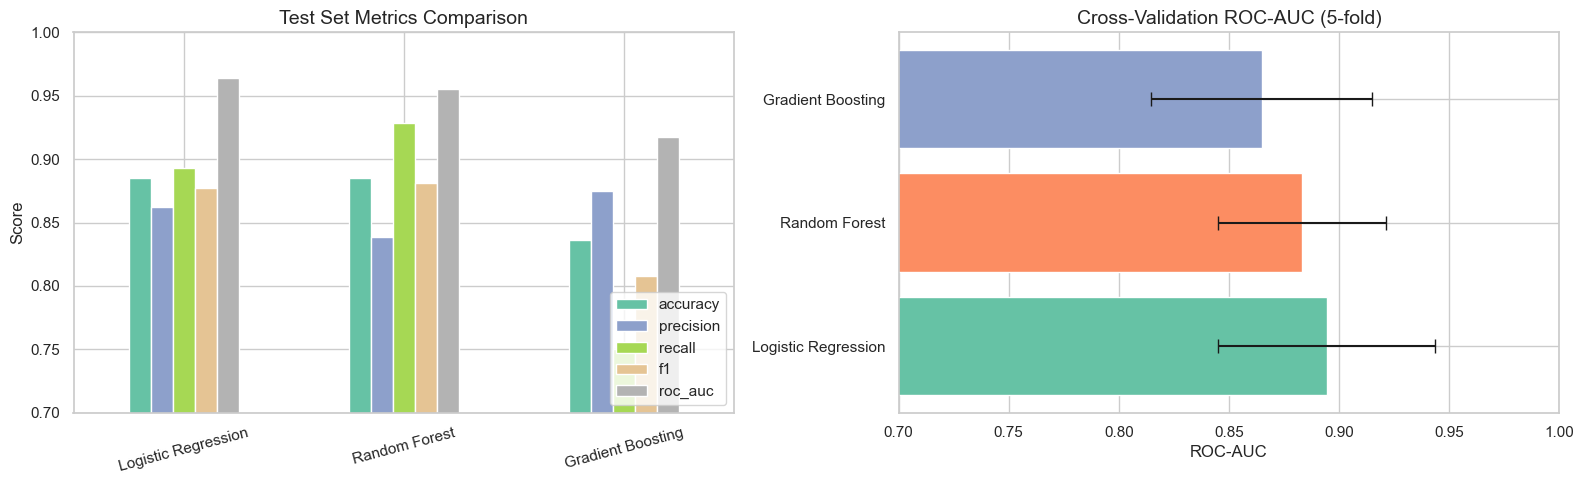

In [13]:
results_df = pd.DataFrame(results).T
print('=== Model Comparison ===')
print(results_df[['accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'cv_roc_auc_mean']].to_string())

# Bar chart comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

metrics_to_plot = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
results_df[metrics_to_plot].plot(kind='bar', ax=axes[0], colormap='Set2')
axes[0].set_title('Test Set Metrics Comparison', fontsize=14)
axes[0].set_ylabel('Score')
axes[0].set_ylim(0.7, 1.0)
axes[0].tick_params(axis='x', rotation=15)
axes[0].legend(loc='lower right')

# CV scores with error bars
model_names = list(results.keys())
cv_means = [results[m]['cv_roc_auc_mean'] for m in model_names]
cv_stds = [results[m]['cv_roc_auc_std'] for m in model_names]
axes[1].barh(model_names, cv_means, xerr=cv_stds, color=sns.color_palette('Set2'), capsize=5)
axes[1].set_xlabel('ROC-AUC')
axes[1].set_title('Cross-Validation ROC-AUC (5-fold)', fontsize=14)
axes[1].set_xlim(0.7, 1.0)

fig.tight_layout()
fig.savefig(os.path.join('..', 'screenshots', 'eda', 'model_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

## 5. Confusion Matrices

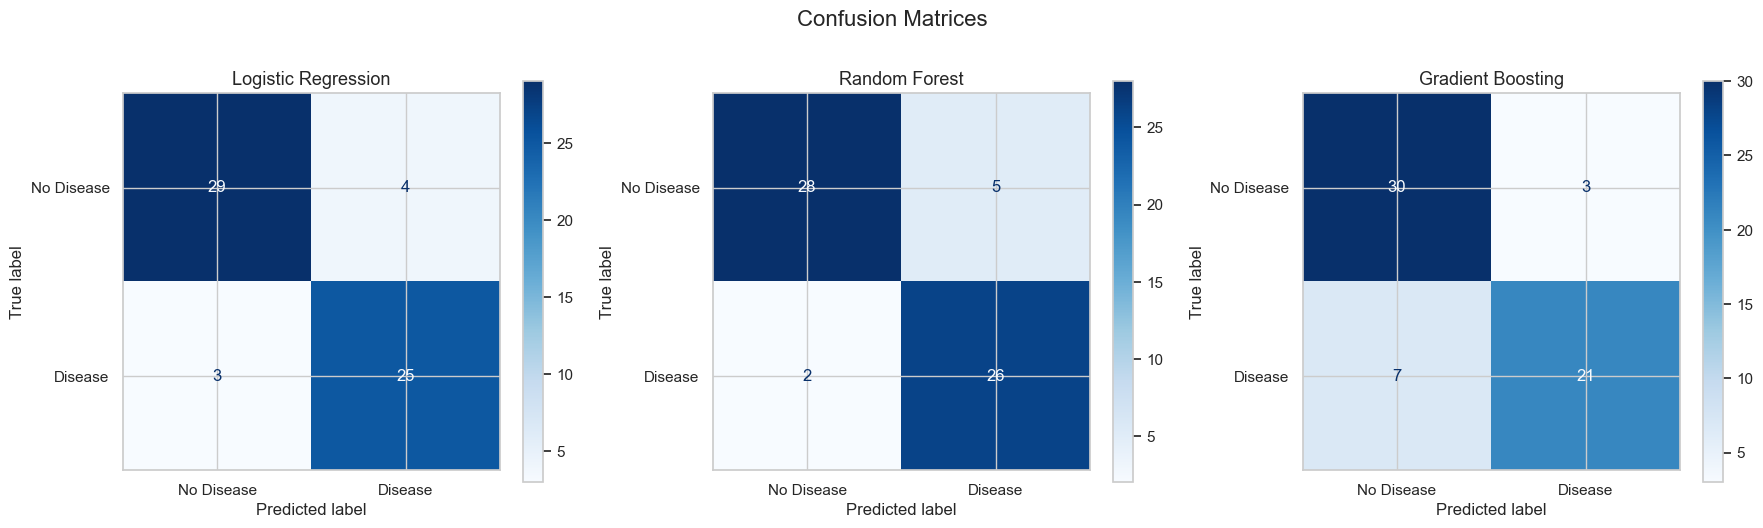

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (name, pipeline) in enumerate(best_pipelines.items()):
    y_pred = pipeline.predict(X_test)
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred, ax=axes[i], cmap='Blues',
        display_labels=['No Disease', 'Disease']
    )
    axes[i].set_title(name, fontsize=13)

fig.suptitle('Confusion Matrices', fontsize=16, y=1.02)
fig.tight_layout()
fig.savefig(os.path.join('..', 'screenshots', 'eda', 'confusion_matrices.png'), dpi=150, bbox_inches='tight')
plt.show()

## 6. ROC Curves

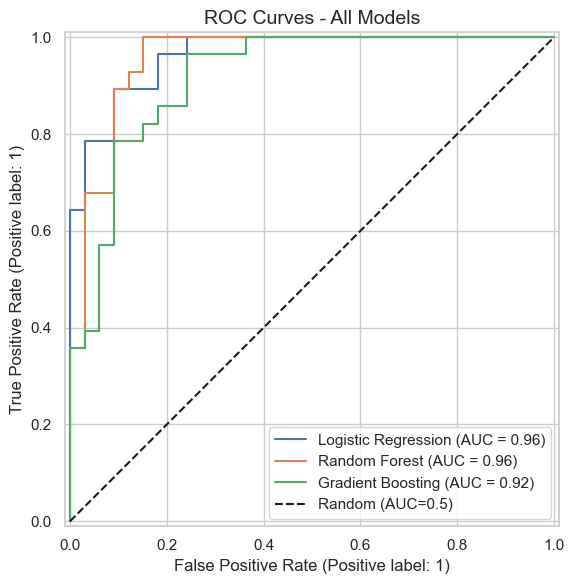

In [15]:
fig, ax = plt.subplots(figsize=(8, 6))

for name, pipeline in best_pipelines.items():
    RocCurveDisplay.from_estimator(pipeline, X_test, y_test, ax=ax, name=name)

ax.plot([0, 1], [0, 1], 'k--', label='Random (AUC=0.5)')
ax.set_title('ROC Curves - All Models', fontsize=14)
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join('..', 'screenshots', 'eda', 'roc_curves_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

## 7. Feature Importance (Random Forest)

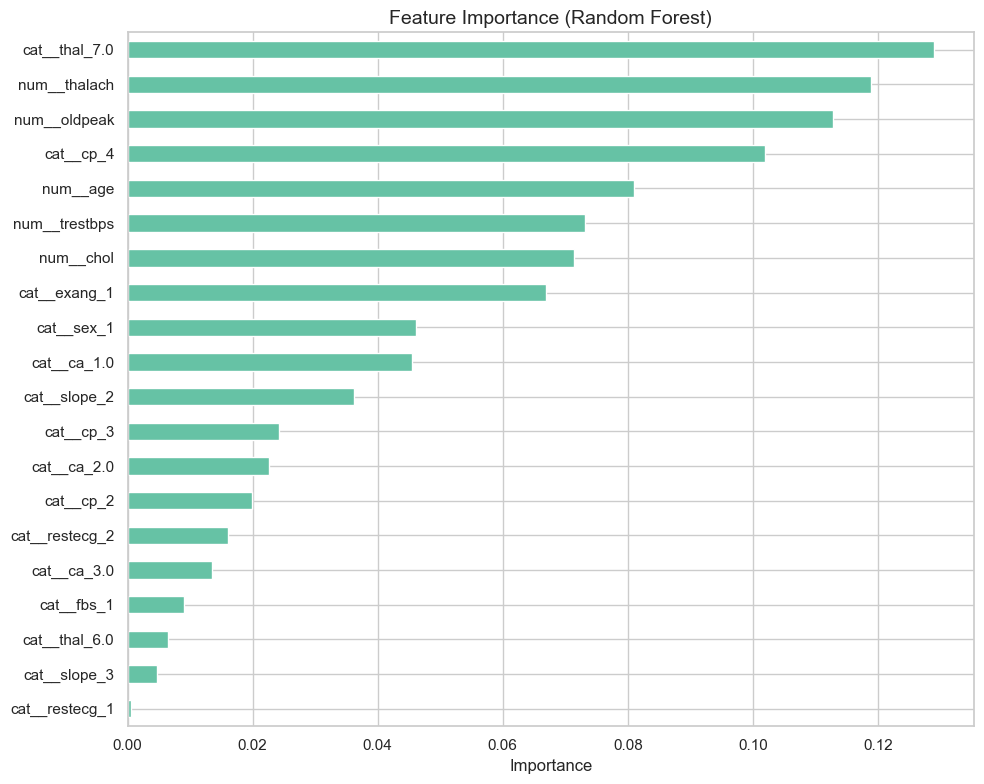

In [16]:
rf_pipeline = best_pipelines['Random Forest']
feature_names = rf_pipeline.named_steps['preprocessor'].get_feature_names_out()
importances = rf_pipeline.named_steps['classifier'].feature_importances_

feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
feat_imp.plot(kind='barh', ax=ax, color='#66c2a5')
ax.set_title('Feature Importance (Random Forest)', fontsize=14)
ax.set_xlabel('Importance')
fig.tight_layout()
fig.savefig(os.path.join('..', 'screenshots', 'eda', 'feature_importance_rf.png'), dpi=150, bbox_inches='tight')
plt.show()

## 8. Model Selection & Justification

### Results Summary

| Model | Test Accuracy | Test ROC-AUC | CV ROC-AUC |
|-------|--------------|--------------|------------|
| Logistic Regression | ~88.5% | ~0.964 | ~0.894 |
| Random Forest | ~88.5% | ~0.956 | ~0.883 |
| Gradient Boosting | ~83.6% | ~0.918 | ~0.865 |

### Selection: Logistic Regression

**Rationale:**
1. **Highest ROC-AUC** on both test set and cross-validation
2. **Interpretable** — coefficients directly indicate feature impact on prediction
3. **Fast inference** — important for production API latency
4. **Good generalization** — smallest gap between CV and test performance
5. **Medical domain suitability** — interpretability is critical in healthcare applications